In [1]:
!pip install yfinance


In [2]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datetime import datetime


In [3]:
symbol = "^NSEI"   # NIFTY 50 Index

start = "2015-01-01"
end = datetime.today().strftime('%Y-%m-%d')


In [4]:
data = yf.download(symbol, start=start, end=end)["Close"]

data.tail()


/tmp/ipykernel_1695/3035218374.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(symbol, start=start, end=end)["Close"]
[*********************100%***********************]  1 of 1 completed


Ticker,^NSEI
Date,
2026-02-25,25482.500000
2026-02-26,25496.550781
2026-02-27,25178.650391
2026-03-02,24865.699219
2026-03-04,24480.500000


In [5]:
returns = data.pct_change().dropna().squeeze()

In [6]:
def classify_regime(r):

    if r > 0.005:
        return "Bull"

    elif r < -0.005:
        return "Bear"

    else:
        return "Neutral"


regimes = returns.apply(classify_regime)

In [7]:
transitions = pd.DataFrame({
    "Today": regimes[:-1].values,
    "Tomorrow": regimes[1:].values
})

transitions.head()


,Today,Tomorrow
0,Neutral,Bear
1,Bear,Neutral
2,Neutral,Bull
3,Bull,Bull
4,Bull,Neutral


In [8]:
transition_matrix = pd.crosstab(
    transitions["Today"],
    transitions["Tomorrow"],
    normalize="index"
)

transition_matrix


Tomorrow,Bear,Bull,Neutral
Today,,,
Bear,0.287561,0.329564,0.382876
Bull,0.175127,0.305838,0.519036
Neutral,0.226696,0.255779,0.517524


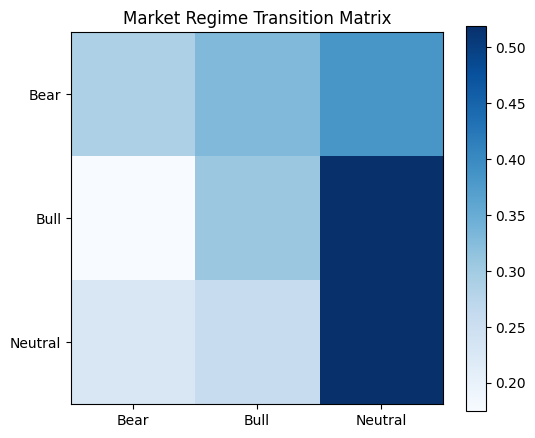

In [9]:
plt.figure(figsize=(6,5))

plt.imshow(transition_matrix, cmap="Blues")

plt.xticks(range(3), transition_matrix.columns)
plt.yticks(range(3), transition_matrix.index)

plt.colorbar()

plt.title("Market Regime Transition Matrix")

plt.show()


In [10]:
current_return = returns.iloc[-1]

current_regime = classify_regime(current_return)

current_regime


'Bear'

In [11]:
prediction = transition_matrix.loc[current_regime]

prediction


,Bear
Tomorrow,
Bear,0.287561
Bull,0.329564
Neutral,0.382876


In [12]:
next_regime = prediction.idxmax()

print("Current Regime:", current_regime)
print("Most Likely Tomorrow:", next_regime)


Current Regime: Bear
Most Likely Tomorrow: Neutral
